In [1]:
import sys


sys.path.append(r"C:\Users\rubenb\OneDrive - SINTEF\Desktop\cluster_exp\quantumreservoirpy")
from reservoirpy.datasets import logistic_map, narma
import numpy as np
import reservoirpy as rpy
import pickle
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge
from quantumreservoirpy.util import create_shifted_array
from qiskit_aer.noise import (NoiseModel, QuantumError, ReadoutError,
    pauli_error, depolarizing_error, thermal_relaxation_error)
from itertools import combinations
from quantumreservoirpy.util import randomIsing
from reservoirpy.nodes import Reservoir
from quantumreservoirpy.partialmeasurement import PartialMeasurement
from quantumreservoirpy.stabilizer import Stabilizer
from qiskit_aer import AerSimulator
import random
from itertools import islice
from collections import defaultdict


In [2]:
def fit_model(model, res_states, series, WARMUP, timeplex=1):
    warmup = int(len(series) * WARMUP)

    X = res_states[warmup:-1]
    y = series[warmup + 1 :]

    model.fit(X, y)

    return model, X, y


def run_prediction(model, res_states, timeplex=1):

    X = np.copy(res_states)

    X = X[-1,:]
    X = X.reshape((1, -1))
    return model.predict(X)

def henon1d(n, a=1.4, b=0.3):
    ts=[0,0]
    for i in range(2,n+2):
        ts.append(1 - a*ts[i-1]**2 + b*ts[i-2])
    return np.array(ts[2:])

In [3]:
num_meas= 2
num_qubits = 3
casename= 'henon'
num_reservoirs = 2
timeplex = 1
method='quantum_part'
noise=None
decode=True
degree=1
tableaunr=10
stab_method='random'
stab_degree=1

In [ ]:

if not degree:
    degree = num_meas
#degree = min(degree, 3)

num_neurons=num_reservoirs*(2**num_meas-1)

if casename == "henon":
    ts = henon1d(30)
elif casename == "logistic":
    ts=logistic_map(30, r=3.9, x0=0.5).flatten()
#ts=narma(200).flatten()
string_identifier="casename"+str(casename)+"_num_qubits"+str(num_qubits)+"_num_meas"+str(num_meas)
string_identifier+="_degree"+str(degree)+"_num_reservoirs"+str(num_reservoirs)+"_timeplex"+str(timeplex)
string_identifier+="_method"+str(method)+"_noise"+str(noise)
if not decode:
    string_identifier+="_decodeFalse"
string_identifier+="_tableaunr"+str(tableaunr)


print(string_identifier, " number of neurons/observables=",num_neurons )



linreg = Ridge(alpha=1e-7)#LinearRegression()



if noise == "None":
    noise_model = None
else:
# Create an empty noise model
    noise_model = NoiseModel()
# Add depolarizing error to all single qubit u1, u2, u3 gates
    error = depolarizing_error(0.01, 1)
    noise_model.add_all_qubit_quantum_error(error, ['u1', 'u2', 'u3'])
    error = depolarizing_error(0.1, 2)
    noise_model.add_all_qubit_quantum_error(error, ['cx'])

WARMUP=0.3

with open("isingparams_"+"num_qubits"+str(num_qubits)+"_num_reservoirs20"+".pickle","rb") as f:
    isingparams = pickle.load(f)
isinparams = dict(islice(isingparams.items(), num_reservoirs))
with open("tableau_"+"num_qubits"+str(num_qubits)+"_num_measurements"+str(num_meas)+"degree"+str(degree)+"_num_tableaus100.pickle","rb") as f:
    tableau = pickle.load(f)
sampled_keys = random.sample(list(tableau.keys()), 1)
sampled_list = [tableau[key] for key in sampled_keys]

# merge and wrap as list of dict
tableau = [{
    'stabilizer': [s for d in sampled_list for s in d['stabilizer']],
    'destabilizer': [s for d in sampled_list for s in d['destabilizer']]
}][0]
print(tableau["stabilizer"])
if method == "classical":
    res = Reservoir(num_neurons, lr=0.5, sr=0.9)
elif method == "quantum_part":
    res = PartialMeasurement(num_qubits, num_meas, backend = AerSimulator(noise_model=noise_model),\
                                degree=degree, num_reservoirs=num_reservoirs, isingparams=isingparams,decode=decode)
elif method == "quantum_stab":
            res = res= Stabilizer(num_qubits, num_meas, tableau=tableau, backend = AerSimulator(noise_model=noise_model),\
                        degree=1,stab_method=stab_method,stab_deg=stab_degree, num_reservoirs=num_reservoirs,decode=True)
tscv = TimeSeriesSplit(n_splits=2)
print(tscv)
for i, (train_index, test_index) in enumerate(tscv.split(ts)):
    print(i)
    X_train=ts[train_index]
    X_test=ts[test_index]
    num_pred = len(test_index)

    with open("X_train"+str(i)+"_"+string_identifier+".pickle","wb") as f:
        pickle.dump(X_train, f)
    with open("X_test"+str(i)+"_"+string_identifier+".pickle","wb") as f:
        pickle.dump(X_test, f)
    
    if method =='classical':
        states = res.run(X_train.reshape(-1, 1), reset=True)
        linreg, X, y = fit_model(linreg, states, X_train, WARMUP, 1)
    else:
        states = res.run(timeseries=X_train, shots=1e3, precision=1e-2, transpile=True)
        linreg, X, y = fit_model(linreg, states, X_train, WARMUP, timeplex)

    score = linreg.score(X, y)
    print("score[",method,"]=", score)
    
    with open("score"+str(i)+"_"+string_identifier+".pickle","wb") as f:
        pickle.dump(score, f)

#        if not method == "classical":
    with open("state"+str(i)+"_"+string_identifier+".pickle","wb") as f:
        pickle.dump(states, f)

    firsttime=True
    prediction = X_train

    for j in range(num_pred):
        print(j,"/",num_pred)
        if method=='classical':
            if firsttime:
                states = res.state()
            else:
                states = res.run(prediction[-1])
            tmp = run_prediction(linreg, states, 1)
        else:
            states = res.run(prediction, shots=1e3, precision=1e-2,transpile=True)
            tmp = run_prediction(linreg, states, timeplex)
        
        prediction = np.append(prediction,tmp)
        print(prediction)
        firsttime=False

    with open("prediction"+str(i)+"_"+string_identifier+".pickle","wb") as f:
        pickle.dump(prediction, f)

casenamehenon_num_qubits3_num_meas2_degree1_num_reservoirs2_timeplex1_methodquantum_part_noiseNone_tableaunr10  number of neurons/observables= 6
['-ZYZ', '+IXX']
TimeSeriesSplit(gap=0, max_train_size=None, n_splits=2, test_size=None)
0


Running reservoirs: 100%|██████████| 2/2 [00:07<00:00,  3.76s/it]


score[ quantum_part ]= 0.4902209561567925
0 / 10


Running reservoirs: 100%|██████████| 2/2 [00:09<00:00,  4.68s/it]


[ 1.         -0.4         1.076      -0.7408864   0.55432228  0.34755162
  0.99718771 -0.28787117  1.18313858 -1.046105    0.01949831]
1 / 10


...

[ 1.         -0.4         1.076      -0.7408864   0.55432228  0.34755162
  0.99718771 -0.28787117  1.18313858 -1.046105   -0.17712836  0.64224426
  0.36939272  1.0016419  -0.29378328  1.17966051 -1.03637347 -0.1497998
  0.65767199  0.34951464  0.13279719  1.72739273 -0.83145429 -1.31935529
 -0.1630158   0.61398155  0.35746443  0.28595065]
8 / 10


Running reservoirs: 100%|██████████| 2/2 [00:18<00:00,  9.35s/it]


[ 1.         -0.4         1.076      -0.7408864   0.55432228  0.34755162
  0.99718771 -0.28787117  1.18313858 -1.046105   -0.17712836  0.64224426
  0.36939272  1.0016419  -0.29378328  1.17966051 -1.03637347 -0.1497998
  0.65767199  0.34951464  0.13279719  1.72739273 -0.83145429 -1.31935529
 -0.1630158   0.61398155  0.35746443  0.28595065  1.05593216]
9 / 10


Running reservoirs: 100%|██████████| 2/2 [00:20<00:00, 10.25s/it]

[ 1.         -0.4         1.076      -0.7408864   0.55432228  0.34755162
  0.99718771 -0.28787117  1.18313858 -1.046105   -0.17712836  0.64224426
  0.36939272  1.0016419  -0.29378328  1.17966051 -1.03637347 -0.1497998
  0.65767199  0.34951464  0.13279719  1.72739273 -0.83145429 -1.31935529
 -0.1630158   0.61398155  0.35746443  0.28595065  1.05593216 -0.48353836]


In [5]:
print(string_identifier)

casenamehenon_num_qubits3_num_meas2_degree1_num_reservoirs2_timeplex1_methodquantum_part_noiseNone_tableaunr10


In [6]:
def get_data(ep, num_qubits, num_meas, method, num_reservoirs,timeplex,noise="None", decode=True):
    degree=1
    string_identifier=str(ep)+"_casename"+str(casename)+"_num_qubits"+str(num_qubits)+"_num_meas"+str(num_meas)
    string_identifier+="_degree"+str(degree)+"_num_reservoirs"+str(num_reservoirs)+"_timeplex"+str(timeplex)
    string_identifier+="_method"+str(method)+"_noise"+str(noise)
    if not decode:
        string_identifier+="_decodeFalse"
    string_identifier+="_tableaunr10"
    string_identifier+=".pickle"
    name="X_train"+string_identifier
    # print("name=",name)
    with open(name,"rb") as f:
        X_train = pickle.load(f)
    
    name="X_test"+string_identifier
    with open(name,"rb") as f:
        X_test = pickle.load(f)
    
    name="score"+string_identifier
    with open(name,"rb") as f:
        score = pickle.load(f)
        
    name="prediction"+string_identifier
    with open(name,"rb") as f:
        prediction = pickle.load(f)
        
    name="state"+string_identifier
    with open(name,"rb") as f:
        state = pickle.load(f)
    return X_train, X_test, score, prediction, state, string_identifier

C:\Users\rubenb\AppData\Local\Temp\ipykernel_20524\2409807420.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


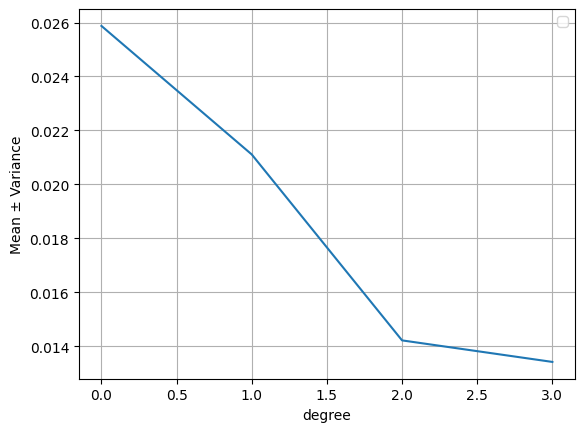

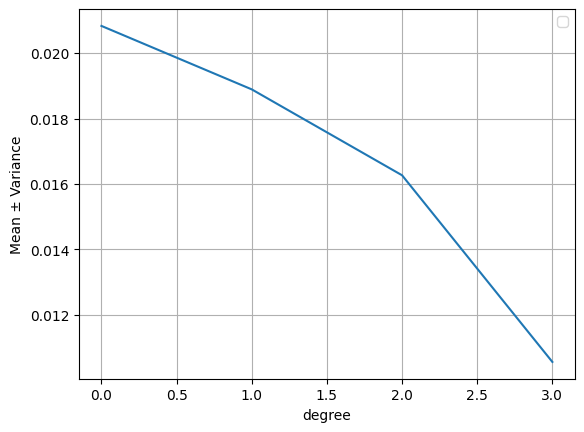

In [7]:
from collections import defaultdict
from matplotlib import pyplot as plt

for ep in [0,1]:
    X_train, X_test, score, prediction, states, basen = get_data(ep, num_qubits, num_meas, "quantum_stab", 20,10, "None")
    data=states
    arr = np.array(data)

    means = np.mean(arr, axis=0)
    stds = np.std(arr, axis=0)

    plt.xlabel("degree")
    plt.ylabel("Mean ± Variance")
    plt.plot(stds)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
X_train, X_test, score, prediction, states, basen = get_data(ep, num_qubits, num_meas, "quantum_stab", 20,10, "None")
plt.plot(np.array(states).T)
plt.show()
corrs=[]
vars=[]
for idx, state in enumerate(states):
    correlation = np.absolute(np.corrcoef(
        (ts[:len(X_train)] - np.mean(ts[:len(X_train)])) / np.std(ts[:len(X_train)]),
        (state - np.mean(state)) / np.std(state)
    )[0, 1])
    var = np.std(state)


    print(f"Pair {idx}: stab={stab}, destab={destab}")
    print("   Variance:", var)
    corrs.append(correlation)
    vars.append(var)
results.append([a,b,[np.mean(corrs),np.std(corrs)],[np.mean(vars),np.std(vars)]])

NameError: name 'ob_train' is not defined

In [ ]:
# Group by n
data=results
groups = defaultdict(list)
for n, m, _ , stats in data:
    mean, var = stats
    x = n
    groups[n].append((x, float(mean), float(var)))

# Plot each group
plt.figure(figsize=(8,6))

for n, values in groups.items():
    values.sort(key=lambda v: v[0])  # sort by x = n/m
    xs = [v[0] for v in values]
    ys = [v[1] for v in values]
    errs = [v[2] for v in values]
    plt.errorbar(xs, ys, yerr=errs, label=f"n = {n}", marker='o', capsize=4)

plt.xlabel("degree")
plt.ylabel("Mean ± Variance")
plt.legend()
plt.grid(True)
plt.show()